In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import gc
from pathlib import Path
from typing import List, Dict, Tuple, Optional
import igraph as ig
import leidenalg as la
from dotenv import load_dotenv
import psycopg2
from sqlalchemy import create_engine, text
import time


env_file = Path("assemble-graph-database/.env")
if env_file.exists():
    load_dotenv(env_file)
    print(f"✓ Loaded environment variables from {env_file}")
else:
    print(f"⚠️  .env file not found at {env_file}")
    print("💡 Using default values")

# Configure display settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print("✓ Libraries imported successfully")
print(f"✓ Pandas version: {pd.__version__}")
print(f"✓ Numpy version: {np.__version__}")

output_dir = Path("analysis_plots")
output_dir.mkdir(exist_ok=True)

✓ Loaded environment variables from assemble-graph-database/.env
✓ Libraries imported successfully
✓ Pandas version: 2.3.2
✓ Numpy version: 2.3.2


### Load igraph Graph

Construct the igraph object from the loaded nodes and edges.

In [3]:
g: ig.Graph = ig.read("../hardrive_mount/projected_graph_with_names_and_communities.graphml")
print(f"✓ Graph loaded from file")
print(f"  Vertices: {g.vcount():,}")
print(f"  Edges: {g.ecount():,}")
print(f"  Directed: {g.is_directed()}")
print(f"\nVertex attributes: {g.vs.attributes()}")
print(f"Edge attributes: {g.es.attributes()}")

✓ Graph loaded from file
  Vertices: 98,101
  Edges: 49,997,708
  Directed: False

Vertex attributes: ['game_id', 'name', 'steam_appid', 'price_currency', 'price_final', 'price_initial', 'release_date', 'rating_dejus_rating', 'rating_dejus_required_age', 'degree', 'component_id', 'projection_degree', 'projection_weighted_degree', 'projection_harmonic_centrality', 'projection_betweenness_centrality', 'leiden_1_5_res_community', 'leiden_0_5_res_community', 'id']
Edge attributes: ['weight']


Number of components: 65,866
Largest component size: 32,220
Smallest component size: 1
Average component size: 1.49


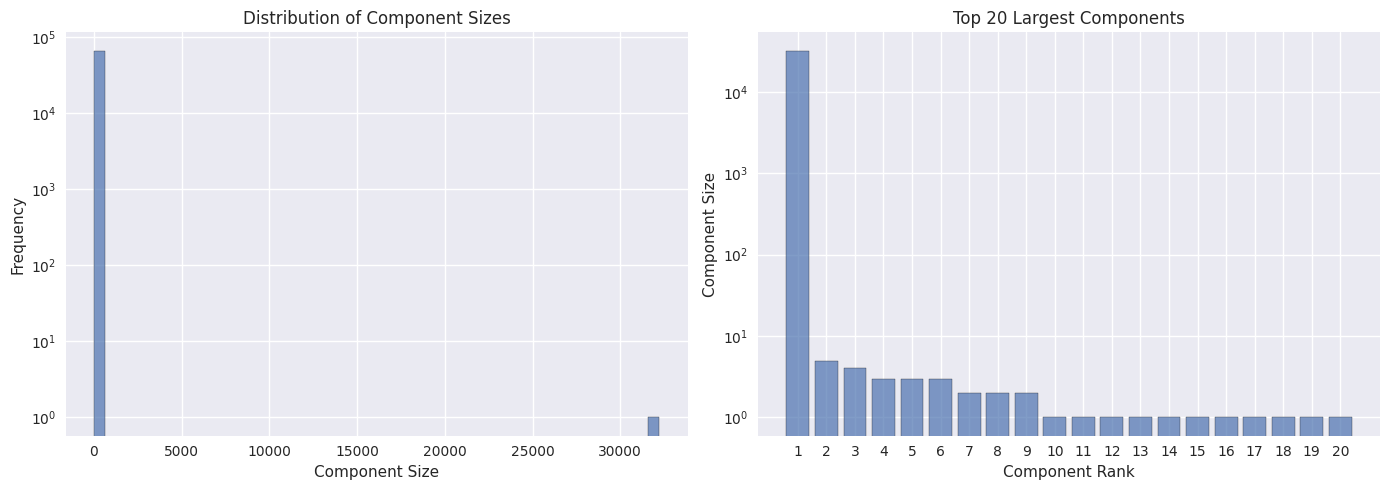


✓ Plot saved to analysis_plots/component_analysis.png


In [5]:
# Count the number of components
components = g.components()
n_components = len(components)
component_sizes = [len(comp) for comp in components]

print(f"Number of components: {n_components:,}")
print(f"Largest component size: {max(component_sizes):,}")
print(f"Smallest component size: {min(component_sizes):,}")
print(f"Average component size: {np.mean(component_sizes):.2f}")

# Create a plot showing component size distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram of component sizes
axes[0].hist(component_sizes, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Component Size')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Component Sizes')
axes[0].set_yscale('log')

# Plot 2: Top 20 largest components
top_20_sizes = sorted(component_sizes, reverse=True)[:20]
axes[1].bar(range(1, len(top_20_sizes) + 1), top_20_sizes, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Component Rank')
axes[1].set_xticks(range(1, len(top_20_sizes) + 1))
axes[1].set_ylabel('Component Size')
axes[1].set_title('Top 20 Largest Components')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig(output_dir / 'component_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Plot saved to {output_dir / 'component_analysis.png'}")

In [6]:
# Display top 10 component sizes
top_10_components = sorted(component_sizes, reverse=True)[:10]
for i, size in enumerate(top_10_components, 1):
  print(f"Component {i}: {size:,} vertices")

Component 1: 32,220 vertices
Component 2: 5 vertices
Component 3: 4 vertices
Component 4: 3 vertices
Component 5: 3 vertices
Component 6: 3 vertices
Component 7: 2 vertices
Component 8: 2 vertices
Component 9: 2 vertices
Component 10: 1 vertices
